In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

INPUT_FILE  = "imu_bicep_reps5.csv"
OUTPUT_FILE = "features_curls_test5.csv"
LABEL       = "bad"
ROMLABEL = "bad"
TEMPOLABEL = "good"
CROP_END    = 830000

df = pd.read_csv(INPUT_FILE)
df_curls = df[df["time_ms"] <= CROP_END].copy()
print(df.shape)
print(df.head())
df.columns

(4601, 7)
     time_ms    ax    ay    az    gx    gy    gz
0  1118700.0 -3.60 -8.54  3.54  0.08 -0.07  0.04
1  1118710.0 -3.48 -8.46  3.50  0.07 -0.08  0.04
2  1118720.0 -3.44 -8.47  3.48  0.08 -0.09  0.03
3  1118730.0 -3.48 -8.47  3.49  0.07 -0.09  0.03
4  1118740.0 -3.54 -8.44  3.54  0.07 -0.07  0.03


Index(['time_ms', 'ax', 'ay', 'az', 'gx', 'gy', 'gz'], dtype='str')

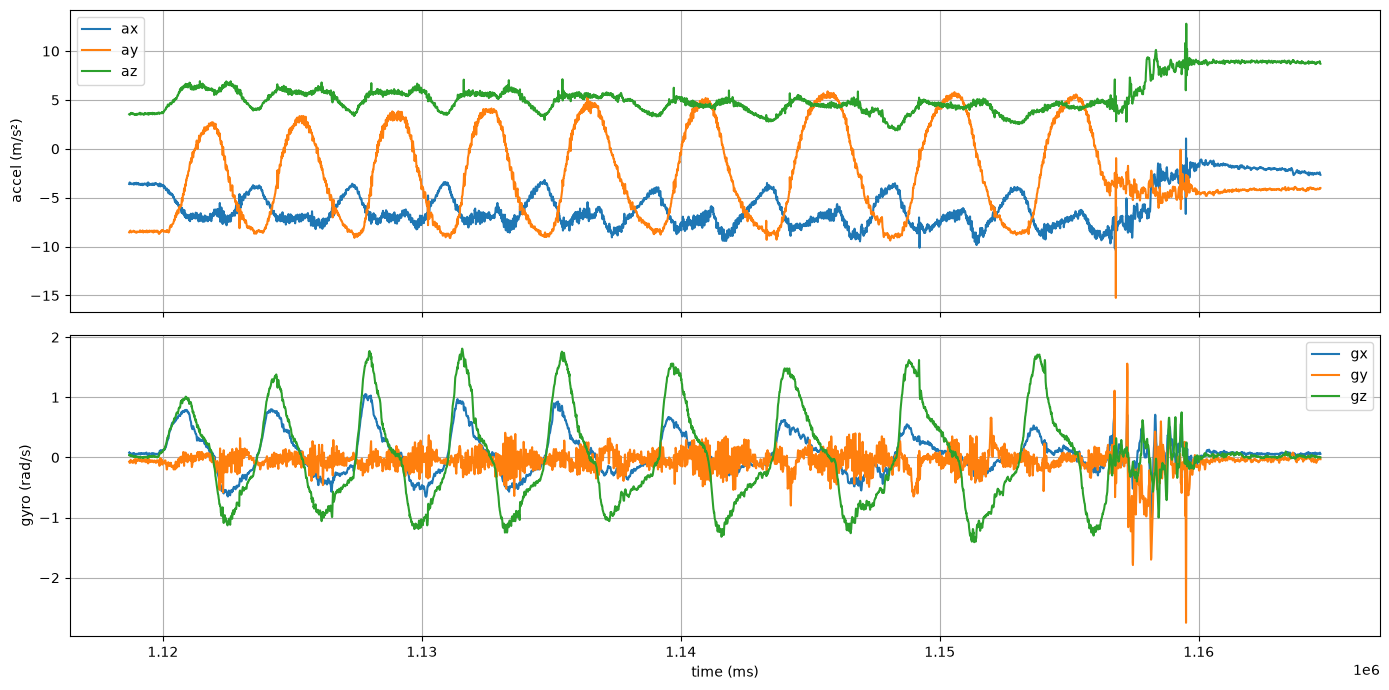

In [106]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# accelerometer on top
ax1.plot(df_curls["time_ms"], df_curls["ax"], label="ax")
ax1.plot(df_curls["time_ms"], df_curls["ay"], label="ay")
ax1.plot(df_curls["time_ms"], df_curls["az"], label="az")
ax1.set_ylabel("accel (m/s²)"); ax1.legend(); ax1.grid(True)

# gyroscope on bottom
ax2.plot(df_curls["time_ms"], df_curls["gx"], label="gx")
ax2.plot(df_curls["time_ms"], df_curls["gy"], label="gy")
ax2.plot(df_curls["time_ms"], df_curls["gz"], label="gz")
ax2.set_ylabel("gyro (rad/s)"); ax2.set_xlabel("time (ms)"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

Estimated rep period: 420 samples
Rep count: 9


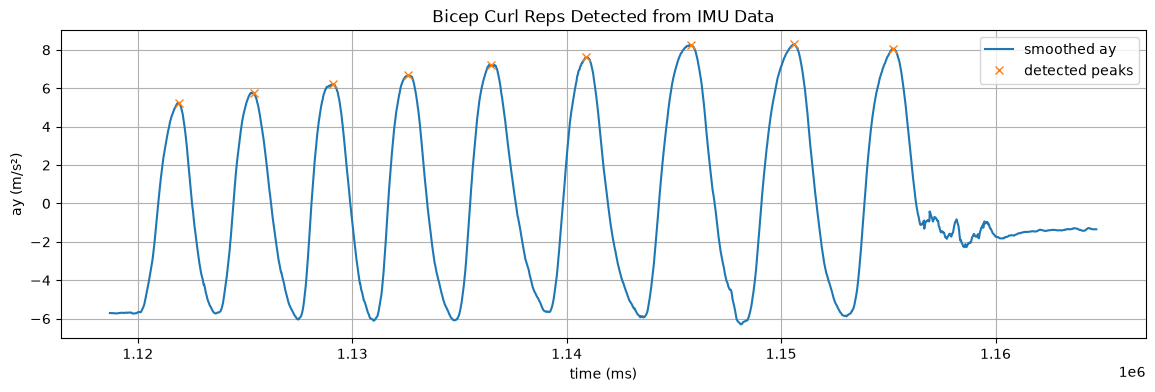

In [107]:
from scipy.signal import find_peaks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sig = df_curls["ay"].rolling(window=25, center=True).mean().bfill().ffill().values
sig = sig - np.mean(sig)          # center it for autocorrelation

# autocorrelation: how well does the signal match a shifted copy of itself?
ac = np.correlate(sig, sig, mode="full")
ac = ac[len(ac)//2:]              # keep the positive-lag half

# the first strong peak in autocorrelation = the repeat period (samples per rep)
ac_peaks, _ = find_peaks(ac, distance=20)
period = ac_peaks[0] if len(ac_peaks) else 100
print(f"Estimated rep period: {period} samples")

# NOW set distance from the measured period — half is a safe choice
peaks, _ = find_peaks(sig, height=0, distance=int(period * 0.5))
print(f"Rep count: {len(peaks)}")
plt.figure(figsize=(14, 4))
plt.plot(df_curls["time_ms"], sig, label="smoothed ay")
plt.plot(df_curls["time_ms"].iloc[peaks], sig[peaks], "x", label="detected peaks")
plt.xlabel("time (ms)"); plt.ylabel("ay (m/s²)"); plt.title("Bicep Curl Reps Detected from IMU Data")
plt.legend(); plt.grid(True); plt.show()

In [108]:
peak_times = df_curls["time_ms"].iloc[peaks].values   # timestamp of each rep

# time between consecutive reps (in ms)
rep_durations = np.diff(peak_times)

consistency = np.std(rep_durations)

print("Time per rep (ms):", rep_durations)
print(f"Average rep duration: {rep_durations.mean():.0f} ms")
print(f"Average tempo: {rep_durations.mean()/1000:.2f} seconds per rep")
print(f"Consistency (std dev): {consistency:.0f} ms")

Time per rep (ms): [3480. 3720. 3460. 3870. 4470. 4860. 4820. 4610.]
Average rep duration: 4161 ms
Average tempo: 4.16 seconds per rep
Consistency (std dev): 554 ms


In [109]:
import numpy as np
import matplotlib.pyplot as plt


# expected rep spacing (samples). measure it or set from known tempo.
EXPECTED = 600        # ~ your rep period in samples
TOLERANCE = 250      # how far from "one period away" still counts

# keep a peak only if another peak sits ~EXPECTED away (either side)
good_peaks = []
for p in peaks:
    has_neighbor = False
    for q in peaks:
        if q == p:
            continue
        gap = abs(q - p)
        if abs(gap - EXPECTED) < TOLERANCE:   # is another peak ~1 period away?
            has_neighbor = True
            break
    if has_neighbor:
        good_peaks.append(p)

print(f"{len(peaks)} candidates -> {len(good_peaks)} after neighbor check")

# good_peaks = your peaks after the neighbor/rhythm filtering
first_peak = good_peaks[0]
last_peak  = good_peaks[-1]

# convert those sample indices to times
start_time = df_curls["time_ms"].iloc[first_peak]
end_time   = df_curls["time_ms"].iloc[last_peak]

# pad a bit so you don't clip the first/last rep's full motion
PAD_MS = 1500   # ~1.5s before first peak and after last
crop = df[(df["time_ms"] >= start_time - PAD_MS) &
          (df["time_ms"] <= end_time   + PAD_MS)].copy()


9 candidates -> 9 after neighbor check


In [110]:
from scipy.signal import find_peaks

ang = np.degrees(np.arctan2(df_curls["ay"], df_curls["az"]))
ang = ang.rolling(window=25, center=True).mean().bfill().ffill().values


valleys, _ = find_peaks(-ang, distance=int(period*0.5) if 'period' in dir() else 50)

# build the full list of ROMs first
roms = []
for p in peaks:
    prior = valleys[valleys < p]
    if len(prior):
        rom = ang[p] - ang[prior[-1]]
        roms.append(abs(rom))      # add each rep's ROM to the list

# NOW trim the first and last, after the list is complete
roms_trimmed = roms[1:-1]
print("ROM per rep (degrees):")
for r in roms_trimmed:
    print(f"  {r:.1f}°")

ROM per rep (degrees):
  92.4°
  98.2°
  102.7°
  107.9°
  115.6°
  122.2°
  1.2°


In [111]:
import pandas as pd
import numpy as np

# how many reps total = how many peaks
n_reps = len(peaks)

# --- ROM: one value per peak, None where it's missing ---
# you already have roms for the valid reps; we need to place them
# at the right positions and leave the edge reps blank.
# easiest: rebuild rom as a full-length list aligned to peaks.

# --- tempo: one value per peak, None for the first rep ---
tempo_full = [None]                      # first rep has no "previous" rep
for i in range(1, n_reps):
    gap = df_curls["time_ms"].iloc[peaks[i]] - df_curls["time_ms"].iloc[peaks[i-1]]
    tempo_full.append(gap)

# --- now all three are length n_reps, so they line up ---
features = pd.DataFrame({
    "rep_number": range(1, n_reps + 1),
    "rom_deg": [None] +roms_trimmed + [None],
    "tempo_ms": tempo_full,
})

features["good_or_bad"] = LABEL     # because this whole session was good reps
features.to_csv(OUTPUT_FILE, index=False)

features["ROM_rating"] = ROMLABEL
features["tempo_rating"] = TEMPOLABEL
features = features[features["rom_deg"] > 20]   # a real curl is way more than 20°

print(features)
features.to_csv(OUTPUT_FILE, index=False)

   rep_number     rom_deg  tempo_ms good_or_bad ROM_rating tempo_rating
1           2   92.448176    3480.0         bad        bad         good
2           3   98.220157    3720.0         bad        bad         good
3           4  102.707242    3460.0         bad        bad         good
4           5  107.896850    3870.0         bad        bad         good
5           6  115.559322    4470.0         bad        bad         good
6           7  122.150712    4860.0         bad        bad         good
